# Vijay Hanumandla
# 23102C0071
# CMPN- C
# Batch - 03

# Experiment-3: Ensemble Learning

## Objective

To implement and analyze different Ensemble Learning techniques for a classification problem and determine which ensemble combination provides the best performance.

### Contents
1. Why Ensemble Learning is required
2. Case Study
3. Data Preparation
4. Base Models
5. Ensemble Learning Techniques
6. Performance Evaluation
7. Comparison and Analysis
8. Conclusion

## 1. Why Ensemble Learning is Required

Ensemble Learning is a machine learning technique in which multiple models are combined to produce a stronger and more reliable predictive model.

A single machine learning model may suffer from:
- High variance
- High bias
- Overfitting
- Poor generalization
- Sensitivity to the training data

Ensemble methods overcome these limitations by combining predictions from multiple models.

The major advantages of Ensemble Learning are:

1. Improved prediction accuracy
2. Better generalization on unseen data
3. Reduced variance
4. Reduced risk of overfitting in certain ensemble methods
5. More robust predictions

Common Ensemble Learning techniques include:
- Bagging
- Random Forest
- AdaBoost
- Gradient Boosting
- Voting
- Stacking

## 2. Case Study Chosen for Implementation

### Breast Cancer Classification

The Breast Cancer Wisconsin dataset is used for this experiment.

The objective is to predict whether a breast tumor is:

- Malignant
- Benign

The dataset contains numerical features calculated from digitized images of breast masses. These features describe characteristics such as radius, texture, perimeter, area, smoothness and other properties.

This is a binary classification problem.

### Why this case study?

The dataset is suitable for Ensemble Learning because:
- It is a classification problem.
- It contains multiple numerical features.
- Different machine learning models can be compared.
- Ensemble methods can combine the strengths of different classifiers.
- Accuracy, precision, recall and F1-score can be used for evaluation.

#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
display(X.head())

print("\nTarget classes:")
print(data.target_names)

Dataset Shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target classes:
['malignant' 'benign']


# Understand the Dataset

In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())


Number of samples: 569
Number of features: 30

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values:
0


# Visualize Target Distribution

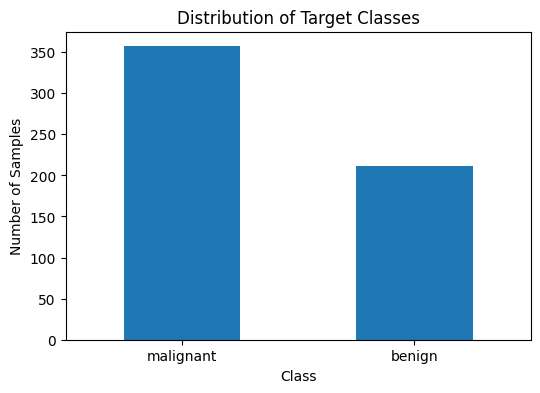

In [4]:
plt.figure(figsize=(6,4))

y.value_counts().plot(kind="bar")

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=data.target_names,
    rotation=0
)

plt.show()

# Split Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


# Feature Scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Create Base Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# Evaluate Base Models

In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1

In [9]:
base_results = []

for name, model in models.items():

    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    base_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

base_results_df = pd.DataFrame(
    base_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(base_results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,KNN,0.956140,0.958904,0.972222,0.965517
3,SVM,0.982456,0.986111,0.986111,0.986111


Vijay 23102C0071
Cmpn-C

# Bagging
Bagging means Bootstrap Aggregating.

It trains multiple models on different samples of the training data and combines their predictions.

Use Decision Trees as base estimators.

In [10]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_accuracy, bagging_precision, bagging_recall, bagging_f1 = evaluate_model(
    bagging,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Bagging Results")
print("Accuracy :", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall   :", bagging_recall)
print("F1 Score :", bagging_f1)

Bagging Results
Accuracy : 0.9385964912280702
Precision: 0.9452054794520548
Recall   : 0.9583333333333334
F1 Score : 0.9517241379310345


# Random Forest
Random Forest is one of the most important ensemble algorithms.

In [11]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(
    random_forest,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


# AdaBoost

In [17]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_accuracy, ada_precision, ada_recall, ada_f1 = evaluate_model(
    adaboost,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("AdaBoost Results")
print("Accuracy :", ada_accuracy)
print("Precision:", ada_precision)
print("Recall   :", ada_recall)
print("F1 Score :", ada_f1)

AdaBoost Results
Accuracy : 0.956140350877193
Precision: 0.9466666666666667
Recall   : 0.9861111111111112
F1 Score : 0.9659863945578231


# Gradient Boosting

In [12]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

gb_accuracy, gb_precision, gb_recall, gb_f1 = evaluate_model(
    gradient_boosting,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Gradient Boosting Results")
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)

Gradient Boosting Results
Accuracy : 0.9473684210526315
Precision: 0.9459459459459459
Recall   : 0.9722222222222222
F1 Score : 0.958904109589041


# Voting Classifier

In [13]:
voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=5000)),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )),
        ("svm", SVC(
            probability=True,
            random_state=42
        ))
    ],
    voting="soft"
)

voting_accuracy, voting_precision, voting_recall, voting_f1 = evaluate_model(
    voting,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Voting Classifier Results")
print("Accuracy :", voting_accuracy)
print("Precision:", voting_precision)
print("Recall   :", voting_recall)
print("F1 Score :", voting_f1)

Voting Classifier Results
Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1 Score : 0.9790209790209791


# Stacking Classifier
Stacking combines several base models and then uses another model called a meta-model to make the final prediction.

In [14]:
stacking = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=5000)),
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ],
    final_estimator=LogisticRegression(max_iter=5000)
)

stacking_accuracy, stacking_precision, stacking_recall, stacking_f1 = evaluate_model(
    stacking,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Stacking Classifier Results")
print("Accuracy :", stacking_accuracy)
print("Precision:", stacking_precision)
print("Recall   :", stacking_recall)
print("F1 Score :", stacking_f1)

Stacking Classifier Results
Accuracy : 0.9736842105263158
Precision: 0.9726027397260274
Recall   : 0.9861111111111112
F1 Score : 0.9793103448275862


# Create Final Comparison Table

In [18]:
ensemble_results = [
    ["Bagging", bagging_accuracy, bagging_precision, bagging_recall, bagging_f1],
    ["Random Forest", rf_accuracy, rf_precision, rf_recall, rf_f1],
    ["AdaBoost", ada_accuracy, ada_precision, ada_recall, ada_f1],
    ["Gradient Boosting", gb_accuracy, gb_precision, gb_recall, gb_f1],
    ["Voting", voting_accuracy, voting_precision, voting_recall, voting_f1],
    ["Stacking", stacking_accuracy, stacking_precision, stacking_recall, stacking_f1]
]

ensemble_df = pd.DataFrame(
    ensemble_results,
    columns=[
        "Ensemble Method",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(
    ensemble_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

,Ensemble Method,Accuracy,Precision,Recall,F1 Score
0,Stacking,0.973684,0.972603,0.986111,0.979310
1,Voting,0.973684,0.985915,0.972222,0.979021
2,AdaBoost,0.956140,0.946667,0.986111,0.965986
3,Random Forest,0.956140,0.958904,0.972222,0.965517
4,Gradient Boosting,0.947368,0.945946,0.972222,0.958904
5,Bagging,0.938596,0.945205,0.958333,0.951724


# Plot Comparison

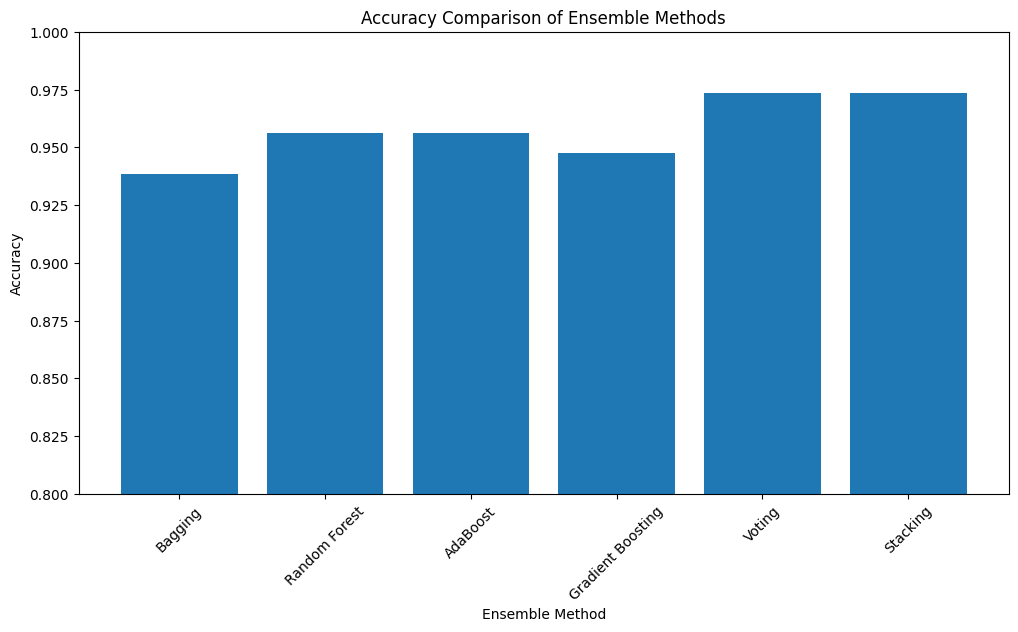

In [19]:
plt.figure(figsize=(12,6))

plt.bar(
    ensemble_df["Ensemble Method"],
    ensemble_df["Accuracy"]
)

plt.xlabel("Ensemble Method")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Ensemble Methods")

plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)

plt.show()

# Compare F1 Score

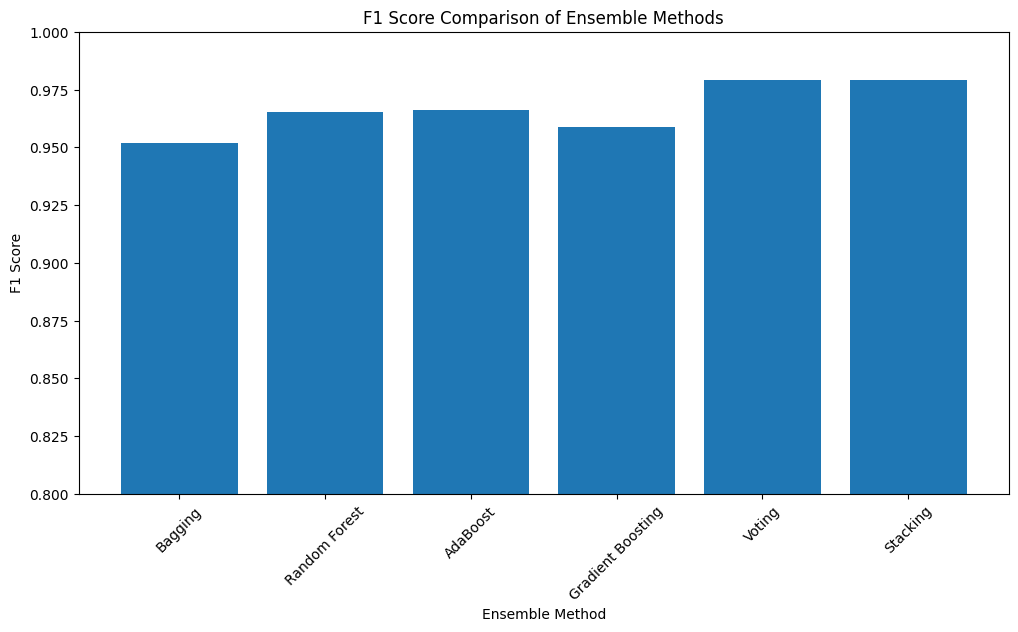

In [20]:
plt.figure(figsize=(12,6))

plt.bar(
    ensemble_df["Ensemble Method"],
    ensemble_df["F1 Score"]
)

plt.xlabel("Ensemble Method")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Ensemble Methods")

plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)

plt.show()

# Find the Best Ensemble Automatically

In [21]:
best_model = ensemble_df.loc[
    ensemble_df["F1 Score"].idxmax()
]

print("Best Ensemble Method:")
print(best_model["Ensemble Method"])

print("\nPerformance:")
print("Accuracy :", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall   :", round(best_model["Recall"], 4))
print("F1 Score :", round(best_model["F1 Score"], 4))

Best Ensemble Method:
Stacking

Performance:
Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793


Vijay 23102C0071
Cmpn-C

# Confusion Matrix for Best Model

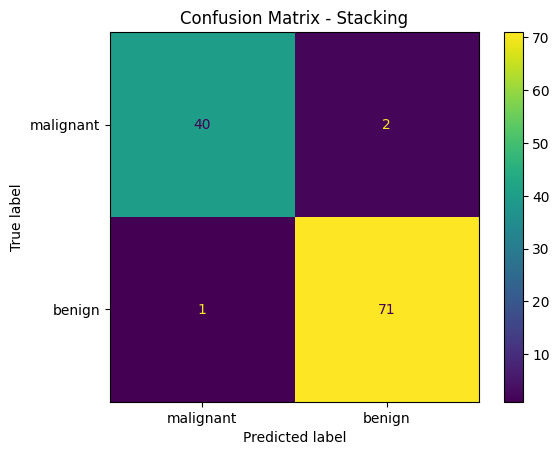

In [22]:
ensemble_models = {
    "Bagging": bagging,
    "Random Forest": random_forest,
    "AdaBoost": adaboost,
    "Gradient Boosting": gradient_boosting,
    "Voting": voting,
    "Stacking": stacking
}

best_name = best_model["Ensemble Method"]
best_ensemble = ensemble_models[best_name]

y_best_pred = best_ensemble.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# Classification Report

In [23]:
print(f"Classification Report for {best_name}")
print()

print(
    classification_report(
        y_test,
        y_best_pred,
        target_names=data.target_names
    )
)

Classification Report for Stacking

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# Analysis Required by the Assignment

## 3. Analysis of Ensemble Methods

The performance of different ensemble learning techniques was compared using Accuracy, Precision, Recall and F1 Score.

### Bagging

Bagging reduces the variance of the model by training multiple models on different bootstrap samples of the training dataset. It is useful when the base model has high variance.

### Random Forest

Random Forest combines multiple decision trees and introduces randomness while selecting features. This generally improves generalization and reduces overfitting compared with a single decision tree.

### AdaBoost

AdaBoost combines weak learners sequentially and gives more importance to incorrectly classified samples. It can provide strong performance but may be sensitive to noisy data.

### Gradient Boosting

Gradient Boosting builds models sequentially, where each new model attempts to correct the errors made by previous models. It can achieve high predictive performance but may require careful parameter tuning.

### Voting

Voting combines predictions from different types of classifiers. In this experiment, Logistic Regression, Random Forest and SVM were combined using soft voting.

The advantage of Voting is that different models can capture different patterns in the data. Soft voting also considers prediction probabilities.

### Stacking

Stacking combines multiple base models and uses a meta-model to learn how to combine their predictions. This can provide better performance when the base models make different types of errors.

### Suitable Ensemble

Based on the experimental results, the ensemble method with the highest F1 Score and strong Accuracy, Precision and Recall is considered the most suitable model for this case study.

F1 Score is particularly important because it provides a balance between Precision and Recall.

Therefore, the final ensemble method is selected based on the experimental results rather than assuming that one technique is always superior.

# Final Conclusion

## Conclusion

In this experiment, different Ensemble Learning techniques were implemented for the Breast Cancer Classification problem.

The implemented techniques included:

- Bagging
- Random Forest
- AdaBoost
- Gradient Boosting
- Voting Classifier
- Stacking Classifier

The models were evaluated using Accuracy, Precision, Recall and F1 Score.

The results demonstrate that ensemble methods can improve prediction performance by combining multiple learners rather than relying on a single machine learning model.

The ensemble method with the highest F1 Score was selected as the most suitable method for this case study because F1 Score provides a balance between Precision and Recall.

Thus, Ensemble Learning provides a robust approach for improving the generalization and predictive performance of machine learning models.
